# 03 - Autoencoder (Anomaly Detection)

Like OCSVM, the autoencoder is trained **only on empty room windows**.
The idea: a network trained to reconstruct normal (empty) CSI will reconstruct
empty windows well and occupied windows poorly because it has never learned
the occupied channel pattern.

At inference we compute the reconstruction error (MSE) for each window.
Windows above a learned threshold are classified as occupied.

**Advantage over OCSVM:** the autoencoder learns a non linear manifold of
normal channel states through gradient descent, rather than fitting a single
hypersphere. This gives it more expressive power for complex channel dynamics.

**This notebook answers:** does a learned reconstruction boundary outperform
the OCSVM anomaly detector across window sizes?

---

## Notebook structure

1. Imports and device setup
2. Data loading and windowing
3. Autoencoder architecture
4. Training loop (empty windows only)
5. Threshold selection and evaluation
6. Ablation across all window sizes

In [1]:
import sys
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

from utils import (
    FEATURE_COLS, WINDOW_SIZES, TEST_SESSIONS,
    load_data, make_windows, session_split, evaluate, plot_ablation,
)

device = (
    torch.device("mps")  if torch.backends.mps.is_available() else
    torch.device("cuda") if torch.cuda.is_available()          else
    torch.device("cpu")
)

EPOCHS     = 50
BATCH_SIZE = 256
LR         = 1e-3
THRESHOLD_SIGMA = 2.0   # threshold = mean_recon_err + std * std_recon_err

print(f"Device : {device}")
print(f"Epochs : {EPOCHS}  |  Batch : {BATCH_SIZE}  |  LR : {LR}")

Device : mps
Epochs : 50  |  Batch : 256  |  LR : 0.001


In [2]:
df = load_data()
print(f"Loaded : {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded : 376,514 rows x 62 columns


## Architecture

We use a fully connected autoencoder with a fixed 110-dimensional input
produced by aggregate_window() (55 mean + 55 std across the time axis).
Encoder and decoder are symmetric, compressing through two hidden layers
down to a bottleneck.

The bottleneck forces the network to learn a compact representation of the
empty room channel state. Anything that doesn't fit that representation
i.e. an occupied window will have high reconstruction error.

| Layer | Type | In => Out | Activation |
|---|---|---|---|
| — | `aggregate_window()` | (N, T, 55) => (N, 110) | — |
| Encoder 1 | `nn.Linear` | 110 => 64 | ReLU |
| Encoder 2 (bottleneck) | `nn.Linear` | 64 => 16 | ReLU |
| Decoder 1 | `nn.Linear` | 16 => 64 | ReLU |
| Decoder 2 | `nn.Linear` | 64 => 110 | — |

> Input is always **110 = 55 mean + 55 std** via `aggregate_window()`
> window size (T) affects the number of samples, not the model architecture.
> Threshold = mean recon error + 2 σ computed on empty training windows only.

In [8]:
def aggregate_window(X: np.ndarray) -> np.ndarray:
    """
    Reduce (n_windows, wsize, n_features) => (n_windows, 2*n_features)
    by concatenating per-feature mean and std across the time axis.
    For W1 (wsize=1) std is 0 that's fine, it's still consistent.
    """
    return np.concatenate([X.mean(axis=1), X.std(axis=1)], axis=1)


class Autoencoder(nn.Module):
    def __init__(self, input_dim: int = 110):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(),
            nn.Linear(64, 16),        nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 64),        nn.ReLU(),
            nn.Linear(64, input_dim),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))


def train_autoencoder(X_empty: np.ndarray, input_dim: int = 110):
    tensor  = torch.tensor(X_empty, dtype=torch.float32)
    loader  = DataLoader(TensorDataset(tensor), batch_size=BATCH_SIZE, shuffle=True)

    model   = Autoencoder(input_dim).to(device)
    optim   = torch.optim.AdamW(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            recon = model(batch)
            loss  = loss_fn(recon, batch)
            optim.zero_grad(); loss.backward(); optim.step()
            epoch_loss += loss.item() * len(batch)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  loss={epoch_loss/len(tensor):.6f}")

    model.eval()
    with torch.no_grad():
        recon = model(tensor.to(device)).cpu().numpy()
    train_errs = ((X_empty - recon) ** 2).mean(axis=1)
    return model, train_errs


def get_recon_errors(model, X: np.ndarray) -> np.ndarray:
    model.eval()
    t = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        recon = model(t).cpu().numpy()
    return ((X - recon) ** 2).mean(axis=1)

## Training & evaluation loop

For each window size:
1. Build windows, split by session
2. Train on empty training windows only
3. Compute reconstruction errors on the training set
4. Set threshold = mean + 2*std of training errors
5. Classify test windows: error > threshold => occupied

In [9]:
from sklearn.preprocessing import StandardScaler

results = {}

for wname, wsize in WINDOW_SIZES.items():
    print(f"\n{'='*50}")
    print(f"{wname}  (window_size={wsize})")

    X, y, sessions = make_windows(df, window_size=wsize)
    X_agg = aggregate_window(X)   # (n_windows, 110) fixed size for all window sizes

    scaler = StandardScaler()
    X_train, X_test, y_train, y_test = session_split(X_agg, y, sessions)

    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    X_train_empty = X_train_sc[y_train == 0]
    print(f"  Train empty={len(X_train_empty):,}  Test={len(y_test):,}  Input_dim=110")

    model, train_errs = train_autoencoder(X_train_empty)

    threshold = train_errs.mean() + THRESHOLD_SIGMA * train_errs.std()
    print(f"  Threshold  : {threshold:.6f}  (mean={train_errs.mean():.6f}  std={train_errs.std():.6f})")

    test_errs = get_recon_errors(model, X_test_sc)
    y_pred    = (test_errs > threshold).astype(int)

    metrics = evaluate(y_test, y_pred, test_errs)
    results[wname] = metrics


W1_snapshot  (window_size=1)
  Train empty=164,169  Test=84,150  Input_dim=110
  Epoch  10/50  loss=0.001068
  Epoch  20/50  loss=0.000884
  Epoch  30/50  loss=0.000811
  Epoch  40/50  loss=0.000798
  Epoch  50/50  loss=0.000789
  Threshold  : 0.001601  (mean=0.000786  std=0.000408)
  Acc=0.7780  F1=0.8110  Prec=0.9905  Rec=0.6866  AUC=0.9368

W2_1s  (window_size=80)
  Train empty=2,049  Test=1,051  Input_dim=110
  Epoch  10/50  loss=0.069316
  Epoch  20/50  loss=0.037799
  Epoch  30/50  loss=0.034677
  Epoch  40/50  loss=0.027664
  Epoch  50/50  loss=0.021797
  Threshold  : 0.073794  (mean=0.021273  std=0.026261)
  Acc=0.9343  F1=0.9510  Prec=0.9867  Rec=0.9177  AUC=0.9821

W3_5s  (window_size=400)
  Train empty=407  Test=209  Input_dim=110
  Epoch  10/50  loss=0.429623
  Epoch  20/50  loss=0.083948
  Epoch  30/50  loss=0.052067
  Epoch  40/50  loss=0.045643
  Epoch  50/50  loss=0.038518
  Threshold  : 0.147467  (mean=0.037947  std=0.054760)
  Acc=0.9043  F1=0.9259  Prec=1.0000  Rec=

## Results

| Window | Train (empty) | Test | F1 | AUC |
|---|---|---|---|---|
| W1 snapshot | 164,169 | 84,150 | 0.8110 | 0.9368 |
| W2 ~1 s | 2,049 | 1,051 | **0.9510** | 0.9821 |
| W3 ~5 s | 407 | 209 | 0.9259 | **0.9849** |
| W4 ~10 s | 201 | 104 | 0.9429 | 0.9562 |

W2 peaks at F1 = 0.951 the autoencoder's best result.

W1 suffers from a structural limitation: with a single row window, the std
half of the 110-dim input vector is always zero. The autoencoder has no
temporal variation to learn from, only the instantaneous amplitude snapshot.
High precision (0.991) but low recall (0.687) suggests the decision boundary
is too tight it only flags windows that are dramatically different from
training, missing subtler occupied states.

W3 drops relative to W2 on F1 but achieves the best AUC in the study (0.985).
Data starvation 407 training windows limits the F1 ceiling, yet the
reconstruction error score remains highly discriminative. W4 partially
recovers F1 to 0.943 with only 201 samples the model memorises the empty
distribution tightly, which paradoxically helps anomaly detection.

Compared to OCSVM: the autoencoder wins at W2 only, OCSVM takes W1, W3, and
W4 on F1. For 1-second windows, learned non-linear reconstruction is the
better anomaly signal, at longer windows the SVM's hypersphere is more robust
to the small training sets available.

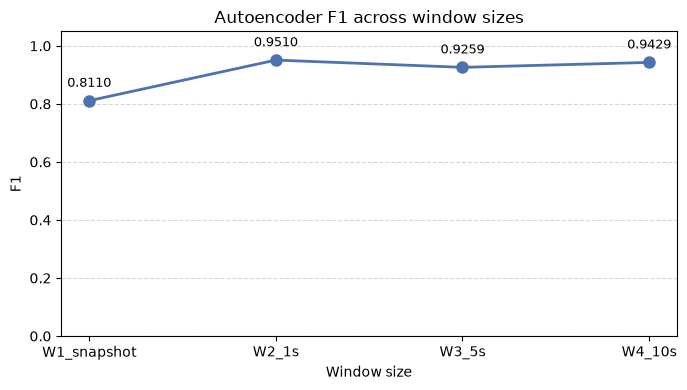

In [10]:
plot_ablation(results, metric="f1", title="Autoencoder F1 across window sizes")

## Conclusion

The autoencoder achieves F1 = 0.951 at W2, clearing the LR baseline (0.856)
and outperforming OCSVM at the 1-second window. It does so without ever seeing
an occupied example purely by learning what "normal" looks like.

The mean+std aggregation keeps the architecture fixed at 110 input dimensions
across all window sizes, making the model lightweight and fast to train on MPS.
The bottleneck (16 units) forces a compact encoding of the empty-room channel
state, reconstruction error is then a clean anomaly signal.